In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
img = cv2.imread('cat.png', 0)

In [3]:
f = np.fft.fft2(img)

In [4]:
# compute the magnitude spectrum
magnitude_spectrum = np.abs(f)

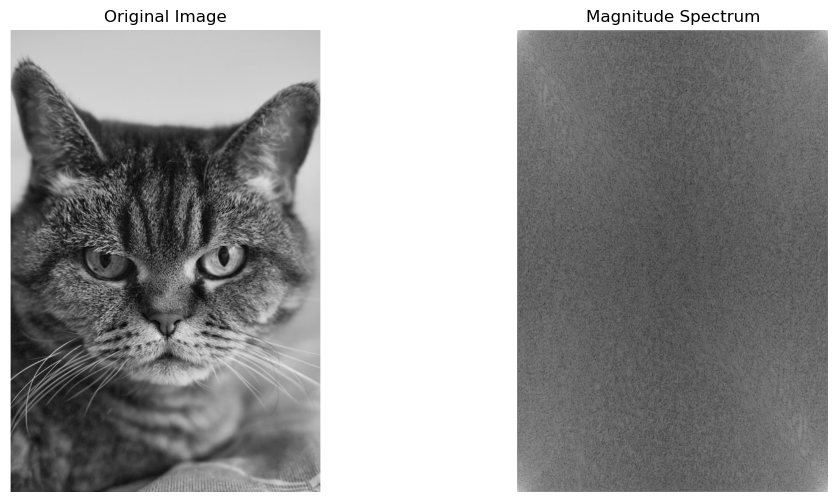

In [5]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Magnitude Spectrum')
plt.imshow(np.log(1 + magnitude_spectrum), cmap='gray')
plt.axis('off')
plt.show()

In [6]:
# Filter the image in the frequency domain
# create a low-pass filter
rows, cols = img.shape
crow, ccol = rows // 2, cols // 2
D0 = 30  # cutoff frequency
u, v = np.meshgrid(np.arange(cols), np.arange(rows))
D = np.sqrt((u - ccol)**2 + (v - crow)**2)
H = (D <= D0).astype(int) 

/tmp/ipykernel_9486/1585129298.py:3: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum_filtered = 20 * np.log(np.abs(fft_filtered))


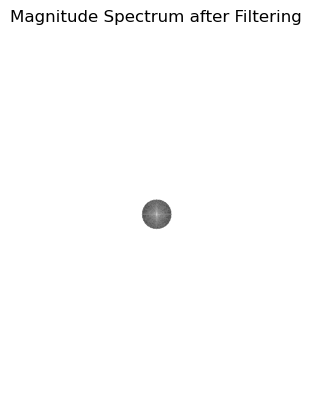

In [10]:
# plot after filtering
fft_filtered = np.fft.fftshift(f) * H
magnitude_spectrum_filtered = 20 * np.log(np.abs(fft_filtered))
plt.title('Magnitude Spectrum after Filtering')
plt.imshow(magnitude_spectrum_filtered, cmap='gray')
plt.axis('off')
plt.show()

/tmp/ipykernel_9486/3018160814.py:5: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum_filtered_high = 20 * np.log(np.abs(fft_filtered_high))


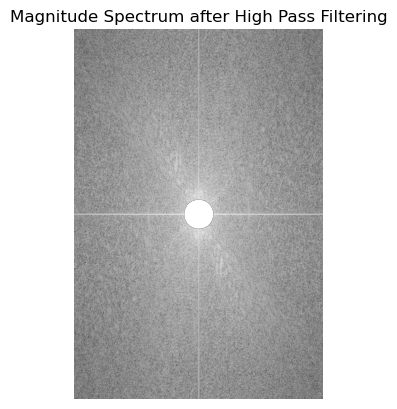

In [11]:
# high pass filter
H_high = (D > D0).astype(int)
# plot after high pass filtering
fft_filtered_high = np.fft.fftshift(f) * H_high
magnitude_spectrum_filtered_high = 20 * np.log(np.abs(fft_filtered_high))
plt.title('Magnitude Spectrum after High Pass Filtering')
plt.imshow(magnitude_spectrum_filtered_high, cmap='gray')
plt.axis('off')
plt.show()